近月合约：TL2603
近月合约：T2603
近月合约：TF2603
近月合约：TS2603
图片已保存: 移仓进度20260317\四大合约持仓量变化_20260317.png


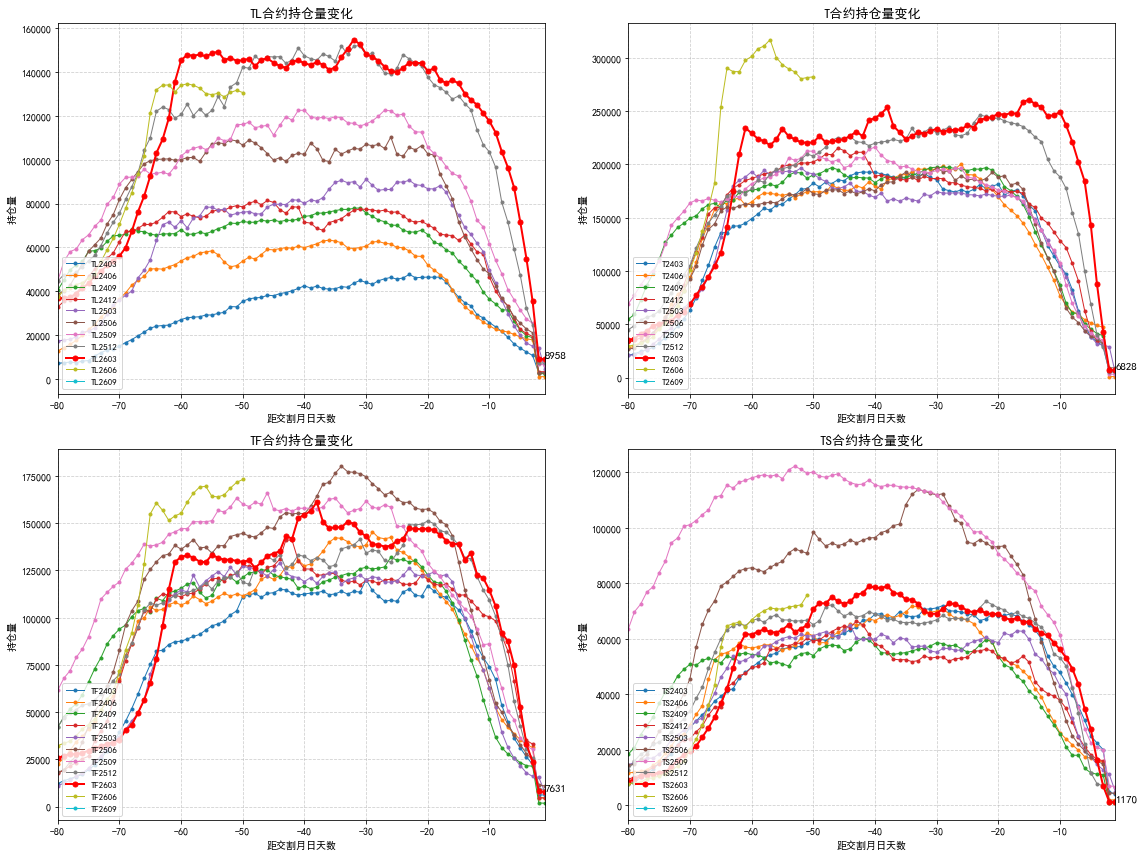

近月合约：TL2609
近月合约：T2609
近月合约：TF2609
近月合约：TS2609
图片已保存: 移仓进度20260317\国债期货移仓进度总览（含持仓量变化）_20260317.png


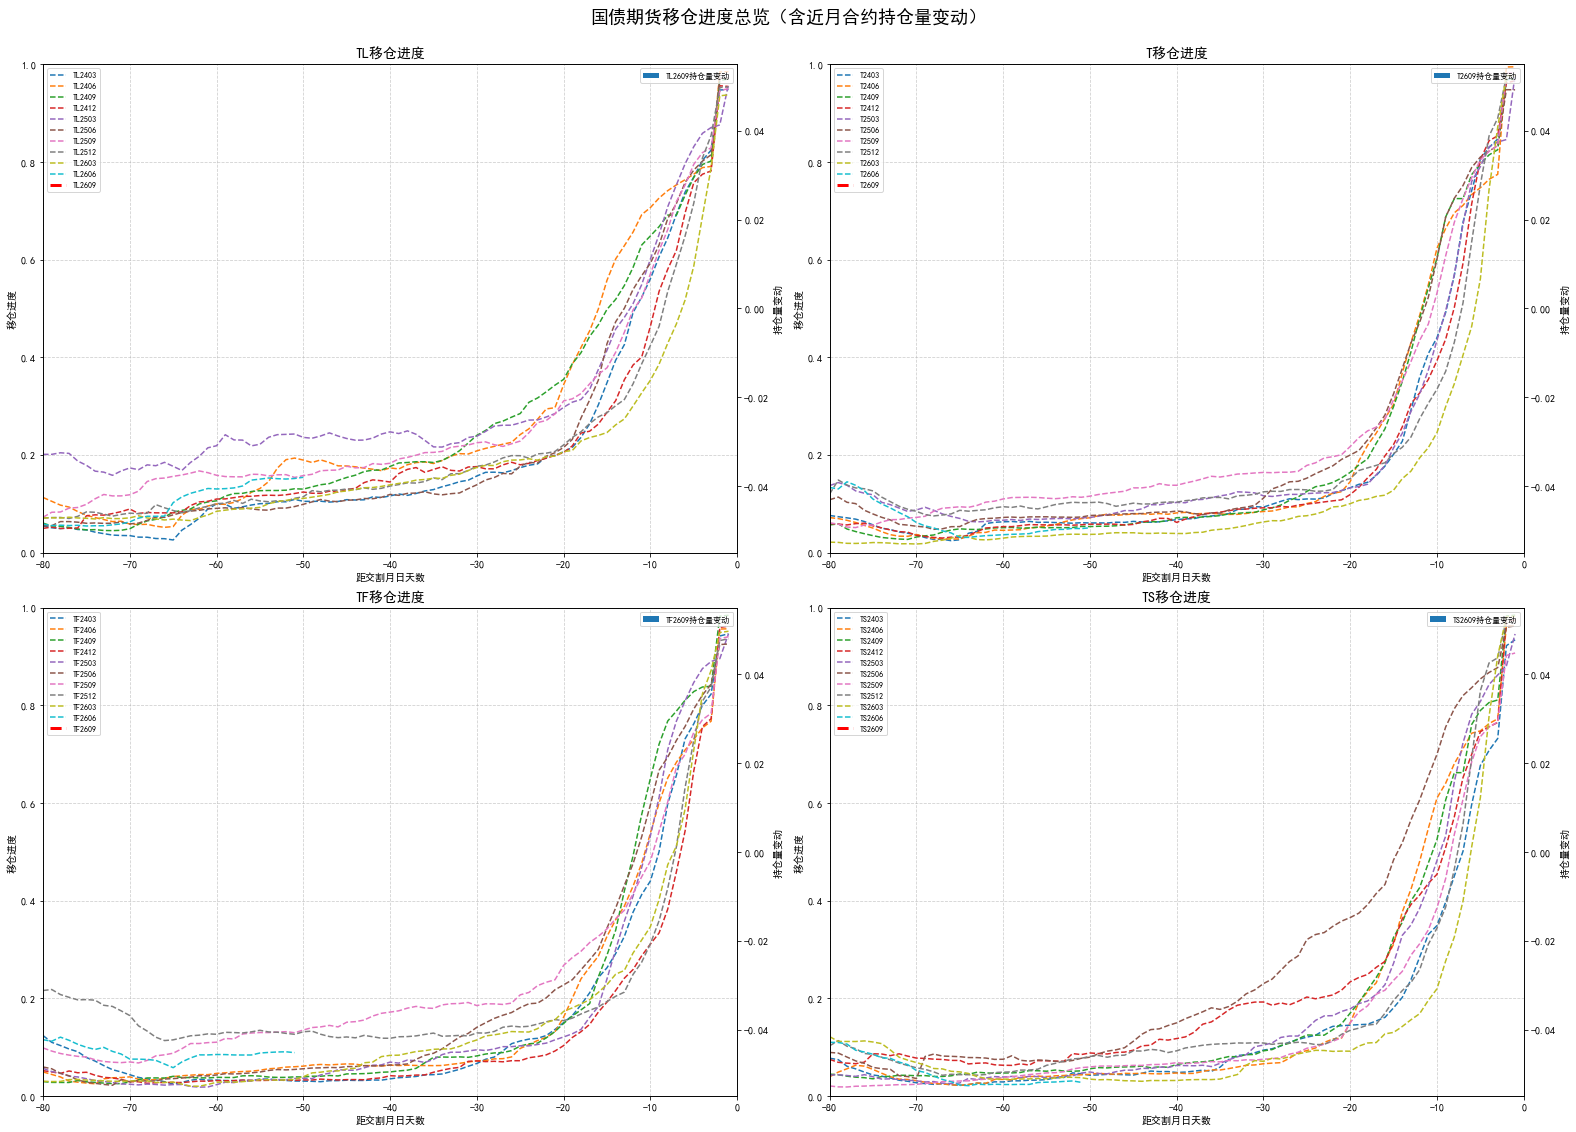

图片已保存: 移仓进度20260317\四大合约移仓进度对比_20260317.png


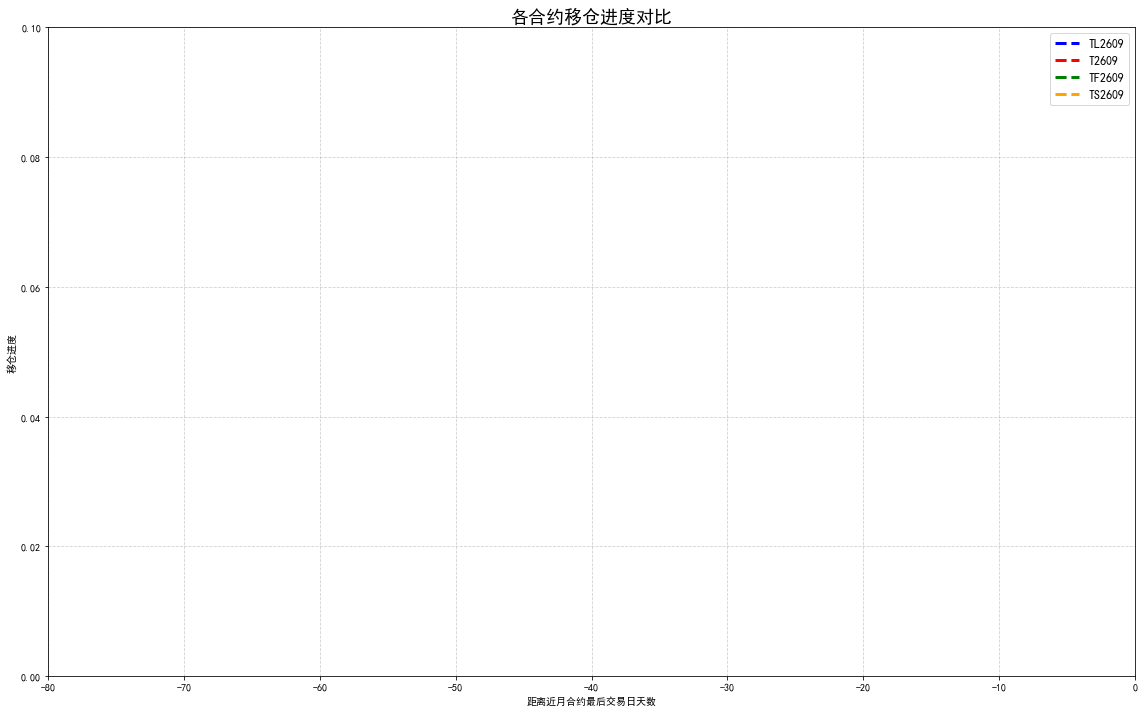

In [ ]:
import pandas as pd
from pandas import DataFrame
import pymysql
import rp  
import ratespricer as rp
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import os


def process_futures_data(fut_list):
    """
    TODO：最后交易日
    获取交割月日前80到前1个交易日的持仓数据
    返回每个合约品种（TL/T/TF/TS)所有合约(TL2403,TL2406,...,最远月合约）：
        posit      近月持仓量
        posit_perc 近月移仓进度 = 远月 / (近月+远月)
    """

    posit = DataFrame()        # 存近月持仓量
    posit_perc = DataFrame()   # 存近月移仓进度

    # 建立数据库连接
    cnn = pymysql.connect(host='192.168.119.53',
                          user='fangyd',
                          passwd='fyd2025!',
                          db='bond2',
                          charset='utf8')
    cur = cnn.cursor()

    # 遍历每组换月合约 (交割日, 近月, 远月)
    for ed, fut_code1, fut_code2 in fut_list:

        sql = '''
            SELECT DateTime, position 
            FROM futures_records_1d_origin 
            WHERE FutCode = '%s' AND DateTime BETWEEN '%s' and '%s'
            '''

        # 计算时间区间：交割日-80（个交易日） 到 交割日-1
        start = rp.d_get_bus_day(ed, -80).strftime('%Y-%m-%d')
        end   = rp.d_get_bus_day(ed, -1).strftime('%Y-%m-%d')

        # 查询近月持仓
        cur.execute(sql % (fut_code1, start, end))
        rst1 = cur.fetchall()

        # 查询远月持仓
        cur.execute(sql % (fut_code2, start, end))
        rst2 = cur.fetchall()

        # 转为 DataFrame
        fut1 = DataFrame.from_records(rst1, columns=['datetimes', 'position'])
        fut2 = DataFrame.from_records(rst2, columns=['datetimes', 'position'])

        # 保存近月持仓
        posit[fut_code1] = fut1['position']

        # 计算移仓进度
        posit_perc[fut_code1] = fut2['position'] / (fut1['position'] + fut2['position'])

    # 索引改为 -80 ~ -1
    posit.index = posit.index - 80
    posit_perc.index = posit_perc.index - 80

    cur.close()
    cnn.close()

    return posit, posit_perc




def plot_combined_oi(posit_dict, contract_types):
    """
    将多个合约持仓量绘制在 2×2 网格图中
    posit_dict: {'TL': df, 'T': df, ...}
    contract_types: ['TL','T','TF','TS']
    """

    # 解决中文与负号显示问题
    plt.rcParams['font.sans-serif'] = ['SimHei']
    plt.rcParams['axes.unicode_minus'] = False

    # 创建 2×2 子图
    fig, axs = plt.subplots(2, 2, figsize=(16, 12))
    axs = axs.flatten()  # 展平成一维数组便于循环

    # 遍历每种合约类型
    for i, contract_type in enumerate(contract_types):
        if i >= len(axs):  # 防止超出子图数量
            break

        ax = axs[i]
        posit = posit_dict[contract_type]  # 当前合约数据
        contracts = list(posit.columns)    # 合约列表
        # TODO：需修改
        Nearby_contract = contracts[-2] if contracts else None  # 筛选出近月合约  
        print(f'近月合约：{Nearby_contract}')

        # 绘制每个合约曲线
        for contract in contracts:
            is_Nearby = (contract == Nearby_contract)

            # 设置样式（最后一个合约加粗红色）
            ax.plot(
                posit.index,
                posit[contract],
                label=contract,
                color='red' if is_Nearby else None,
                linewidth=2 if is_Nearby else 1,
                marker='o',
                markersize=5 if is_Nearby else 3
            )

            # 若为近月合约，标注最后一个有效值
            if is_Nearby:
                valid = posit[contract].dropna()
                if not valid.empty:
                    ax.text(
                        valid.index[-1],
                        valid.iloc[-1],
                        f'{valid.iloc[-1]:.0f}',
                        fontsize=11,
                        fontweight='bold',
                        ha='left',
                        va='bottom'
                    )

        # 子图格式设置
        ax.set_title(f'{contract_type}合约持仓量变化', fontsize=13)
        ax.set_xlabel('距交割月日天数')
        ax.set_ylabel('持仓量')
        ax.legend(loc='lower left', fontsize=9)
        ax.grid(True, linestyle='--', alpha=0.6)

        if not posit.empty:
            ax.set_xlim(posit.index.min(), posit.index.max())

    plt.tight_layout()

    # === 保存图片 ===
    today = datetime.now().strftime('%Y%m%d')
    result_folder = 'result'
    os.makedirs(result_folder, exist_ok=True)

    filename = f'四大合约持仓量变化_{today}.png'
    file_path = os.path.join(result_folder, filename)

    plt.savefig(file_path, dpi=300, bbox_inches='tight')
    print(f'图片已保存: {file_path}')

    plt.show()


# 绘制移仓进度对比图（含持仓量变动）
def plot_roll_overview(data_dict):
    """
    data_dict = {
        'TL': (posit, posit_perc),
        'T':  (posit, posit_perc),
        ...
    }
    """
    
    # 设置中文字体和负号正常显示
    plt.rcParams['font.sans-serif'] = ['SimHei']
    plt.rcParams['axes.unicode_minus'] = False

    # 创建2×2子图
    fig, axes = plt.subplots(2, 2, figsize=(22, 16))
    axes = axes.flatten()  # 展平便于循环

    today = datetime.now().strftime('%Y%m%d')  # 获取今日日期

    # 遍历每个品种
    for i, (product, (posit, posit_perc)) in enumerate(data_dict.items()):

        ax = axes[i]  # 当前子图

        Nearby_contract = posit_perc.columns[-1]  # 筛选出近月合约
        print(f'近月合约：{Nearby_contract}')

        # ===== 左轴：移仓进度曲线 =====
        for col in posit_perc.columns:

            is_Nearby = (col == Nearby_contract)

            # ★修改：所有合约都改为虚线
            ax.plot(
                posit_perc.index,
                posit_perc[col],
                linestyle='--',              # ★修改
                linewidth=3 if is_Nearby else 1.5,
                color='red' if is_Nearby else None,
                label=col,
                zorder=2                    # ★新增：控制图层
            )

            # 近月标注最后一个有效点
            if is_Nearby:
                valid = posit_perc[col].dropna()
                if not valid.empty:
                    last_x = valid.index[-1]
                    last_y = valid.iloc[-1]

                    ax.scatter(last_x, last_y, s=80, color='darkred', zorder=5)  # ★修改zorder

                    # ★修改：置于柱子之上
                    ax.annotate(
                        f"({last_x:.0f}, {last_y:.3f})",
                        (last_x, last_y),
                        xytext=(10, 10),
                        textcoords='offset points',
                        fontsize=16,
                        fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.3',
                                  facecolor='red',
                                  alpha=0.9),
                        arrowprops=dict(arrowstyle='->',
                                        color='darkred'),
                        zorder=6  # ★新增：最高图层
                    )

        # 左轴格式设置
        ax.set_title(f"{product}移仓进度", fontsize=14, fontweight='bold')
        ax.set_xlabel('距交割月日天数')
        ax.set_ylabel('移仓进度')
        ax.set_xlim(-80, 0)
        ax.set_ylim(0, 1)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend(fontsize=8, loc='upper left')

        # ===== 右轴：近月持仓变动 =====
        ax_right = ax.twinx()  # 创建右侧Y轴

        if Nearby_contract in posit.columns:

            oi = posit[Nearby_contract].diff().dropna()

            x_vals = oi.index
            y_vals = oi.values

            colors = ['red' if y > 0 else 'green' for y in y_vals]

            # ★修改：增加黑色实线边框
            bars = ax_right.bar(
                x_vals,
                y_vals,
                color=colors,
                edgecolor='black',      # ★新增
                linewidth=0.6,          # ★新增
                alpha=0.7,
                width=1.0,
                label=f"{Nearby_contract}持仓量变动",
                zorder=1               # ★新增：柱子在底层
            )

            ax_right.set_ylabel("持仓量变动")
            ax_right.tick_params(axis='y')

            if len(y_vals) > 0:
                max_val = max(abs(y_vals.max()), abs(y_vals.min()))
                ax_right.set_ylim(-max_val * 1.2, max_val * 1.2)

            # 标注最后一个柱子
            if len(x_vals) > 0:
                last_x = x_vals[-1]
                last_y = y_vals[-1]

                bbox_color = 'lightcoral' if last_y > 0 else 'lightgreen'
                edge_color = 'darkred' if last_y > 0 else 'darkgreen'

                ax_right.annotate(
                    f'{last_y:.0f}',
                    xy=(last_x, last_y),
                    xytext=(0, 15),
                    textcoords='offset points',
                    ha='center',
                    fontsize=16,
                    fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3',
                              facecolor=bbox_color,
                              edgecolor=edge_color),
                    arrowprops=dict(arrowstyle='->',
                                    color=edge_color),
                    zorder=3   # ★新增：在柱子之上但低于移仓点
                )

            ax_right.legend(loc='upper right', fontsize=8)

    # 设置总标题
    plt.suptitle("国债期货移仓进度总览（含近月合约持仓量变动）",
                 fontsize=18,
                 fontweight='bold')

    plt.tight_layout()
    plt.subplots_adjust(top=0.93)

    # === 保存图片 ===
    today = datetime.now().strftime('%Y%m%d')
    result_folder = 'result'
    os.makedirs(result_folder, exist_ok=True)

    filename = f'国债期货移仓进度总览（含持仓量变化）_{today}.png'
    file_path = os.path.join(result_folder, filename)

    plt.savefig(file_path, dpi=300, bbox_inches='tight')
    print(f'图片已保存: {file_path}')

    plt.show()

def plot_roll_contrast(data_dict):
    """
    画四个品种（TL/T/TF/TS）近月合约移仓进度对比图
    data_dict = {
        'TL': (posit, posit_perc),
        'T':  (posit, posit_perc),
        'TF': (posit, posit_perc),
        'TS': (posit, posit_perc),
    }
    """

    # 设置中文字体和负号正常显示
    plt.rcParams['font.sans-serif'] = ['SimHei']
    plt.rcParams['axes.unicode_minus'] = False

    fig, ax = plt.subplots(figsize=(16, 10))

    # 为四个品种指定固定颜色（与示意图风格一致）
    color_map = {
        'TL': 'blue',
        'T': 'red',
        'TF': 'green',
        'TS': 'orange'
    }

    for product, (posit, posit_perc) in data_dict.items():

        if posit_perc.empty:
            continue

        # 近月合约（与你原逻辑保持一致）
        Nearby_contract = posit_perc.columns[-2]

        x = posit_perc.index
        y = posit_perc[Nearby_contract]

        ax.plot(
            x,
            y,
            linestyle='--',
            linewidth=3,
            color=color_map.get(product, None),
            label=f"{Nearby_contract}",
            zorder=2
        )

        # 标注最后一个有效点
        valid = y.dropna()
        if not valid.empty:
            last_x = valid.index[-1]
            last_y = valid.iloc[-1]

            ax.scatter(
                last_x,
                last_y,
                s=120,
                color=color_map.get(product, None),
                zorder=5
            )

            ax.annotate(
                f"({last_x:.0f}, {last_y:.3f})",
                (last_x, last_y),
                xytext=(10, 10),
                textcoords='offset points',
                fontsize=14,
                fontweight='bold',
                bbox=dict(
                    boxstyle='round,pad=0.3',
                    facecolor=color_map.get(product, 'gray'),
                    alpha=0.8
                ),
                arrowprops=dict(
                    arrowstyle='->',
                    color=color_map.get(product, 'black')
                ),
                zorder=6
            )

    # 图形格式
    ax.set_title("各合约移仓进度对比", fontsize=18, fontweight='bold')
    ax.set_xlabel("距交割月日天数")
    ax.set_ylabel("移仓进度")
    ax.set_xlim(-80, 0)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=12)

    plt.tight_layout()

    # 保存图片
    today = datetime.now().strftime('%Y%m%d')
    result_folder = 'result'
    os.makedirs(result_folder, exist_ok=True)

    filename = f'四大合约移仓进度对比_{today}.png'
    file_path = os.path.join(result_folder, filename)

    plt.savefig(file_path, dpi=300, bbox_inches='tight')
    print(f'图片已保存: {file_path}')

    plt.show()

def plot_roll_contrast(data_dict):
    """
    四大品种近月合约移仓进度对比图
    Y轴自适应：
        - 最大值 > 0.9 时封顶 1.0
        - 否则按 0.1 为最小单位向上取整 + 0.1 缓冲
    """

    # ===== 基础图形设置 =====
    plt.rcParams['font.sans-serif'] = ['SimHei']      # 解决中文显示
    plt.rcParams['axes.unicode_minus'] = False        # 解决负号显示

    fig, ax = plt.subplots(figsize=(16, 10))          # 创建单图

    # ===== 颜色映射（固定品种颜色）=====
    color_map = {
        'TL': 'blue',
        'T': 'red',
        'TF': 'green',
        'TS': 'orange'
    }

    # ===== 标注偏移映射（避免重叠）=====
    offset_map = {
        'TL': (15, 20),
        'T':  (15, -30),
        'TF': (-80, 20),
        'TS': (-80, -30)
    }

    global_max_y = 0   # 记录四个品种中的最大移仓值

    # ===== 遍历每个品种 =====
    for product, (posit, posit_perc) in data_dict.items():

        if posit_perc.empty:      # 若数据为空则跳过
            continue

        Nearby_contract = posit_perc.columns[-1]   # 获取近月合约

        x = posit_perc.index                      # 横轴：距离交割日天数
        y = posit_perc[Nearby_contract]           # 纵轴：近月移仓进度

        # 更新全局最大值
        local_max = y.max()
        if pd.notna(local_max):
            global_max_y = max(global_max_y, local_max)

        # ===== 绘制移仓进度曲线 =====
        ax.plot(
            x,
            y,
            linestyle='--',                        # 虚线
            linewidth=3,                           # 加粗
            color=color_map.get(product, None),    # 固定颜色
            label=Nearby_contract,                 # 图例显示合约
            zorder=2                               # 图层控制
        )

        # ===== 标注最后一个有效点 =====
        valid = y.dropna()                         # 去除空值
        if not valid.empty:

            last_x = valid.index[-1]               # 最后一个X
            last_y = valid.iloc[-1]                # 最后一个Y

            # 绘制终点圆点
            ax.scatter(
                last_x,
                last_y,
                s=120,
                color=color_map.get(product, None),
                zorder=5
            )

            # 获取对应偏移方向
            dx, dy = offset_map.get(product, (10, 10))

            # 添加带箭头标注
            ax.annotate(
                f"({last_x:.0f}, {last_y:.3f})",
                (last_x, last_y),
                xytext=(dx, dy),
                textcoords='offset points',
                fontsize=14,
                fontweight='bold',
                bbox=dict(
                    boxstyle='round,pad=0.3',
                    facecolor=color_map.get(product, 'gray'),
                    alpha=0.85
                ),
                arrowprops=dict(
                    arrowstyle='->',
                    color=color_map.get(product, 'black')
                ),
                zorder=6
            )

    # ===== Y轴自适应逻辑 =====

    if global_max_y > 0.9:
        upper = 1.0     # 若接近完成移仓，则封顶1.0
    elif global_max_y == 0:
        upper = 0.1     # 若数据异常，则给最小刻度
    else:
        # 向上取整到0.1倍数
        upper = np.ceil(global_max_y / 0.1) * 0.1
        upper += 0.1    # 额外留出0.1缓冲空间

    # 设置坐标轴范围
    ax.set_ylim(0, upper)
    ax.set_xlim(-80, 0)

    # ===== 图形格式 =====
    ax.set_title("各合约移仓进度对比", fontsize=18, fontweight='bold')
    ax.set_xlabel("距离近月合约最后交易日天数")
    ax.set_ylabel("移仓进度")
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=12)

    plt.tight_layout()

    # ===== 保存图片 =====
    today = datetime.now().strftime('%Y%m%d')
    result_folder = 'result'
    os.makedirs(result_folder, exist_ok=True)

    filename = f'四大合约移仓进度对比_{today}.png'
    file_path = os.path.join(result_folder, filename)

    plt.savefig(file_path, dpi=300, bbox_inches='tight')
    print(f'图片已保存: {file_path}')

    plt.show()

    
if __name__ == "__main__":
    # 定义：近月合约的交割月，近月合约，远月合约
    fut_TL_list = [
        ('2024-03-01', 'TL2403', 'TL2406'),
        ('2024-06-01', 'TL2406', 'TL2409'),
        ('2024-09-01', 'TL2409', 'TL2412'),
        ('2024-12-01', 'TL2412', 'TL2503'),
        ('2025-03-01', 'TL2503', 'TL2506'),
        ('2025-06-01', 'TL2506', 'TL2509'),
        ('2025-09-01', 'TL2509', 'TL2512'),
        ('2025-12-01', 'TL2512', 'TL2603'),
        ('2026-03-01', 'TL2603', 'TL2606'),
        ('2026-06-01', 'TL2606', 'TL2609'),
        ('2026-09-01', 'TL2609', 'TL2612'),
    ]

    fut_T_list = [
        ('2024-03-01', 'T2403', 'T2406'),
        ('2024-06-01', 'T2406', 'T2409'),
        ('2024-09-01', 'T2409', 'T2412'),
        ('2024-12-01', 'T2412', 'T2503'),
        ('2025-03-01', 'T2503', 'T2506'),
        ('2025-06-01', 'T2506', 'T2509'),
        ('2025-09-01', 'T2509', 'T2512'),
        ('2025-12-01', 'T2512', 'T2603'),
        ('2026-03-01', 'T2603', 'T2606'),
        ('2026-06-01', 'T2606', 'T2609'),
        ('2026-09-01', 'T2609', 'T2612'),
    ]

    fut_TF_list = [
        ('2024-03-01', 'TF2403', 'TF2406'),
        ('2024-06-01', 'TF2406', 'TF2409'),
        ('2024-09-01', 'TF2409', 'TF2412'),
        ('2024-12-01', 'TF2412', 'TF2503'),
        ('2025-03-01', 'TF2503', 'TF2506'),
        ('2025-06-01', 'TF2506', 'TF2509'),
        ('2025-09-01', 'TF2509', 'TF2512'),
        ('2025-12-01', 'TF2512', 'TF2603'),
        ('2026-03-01', 'TF2603', 'TF2606'),
        ('2026-06-01', 'TF2606', 'TF2609'),
        ('2026-09-01', 'TF2609', 'TF2612'),
    ]

    fut_TS_list = [
        ('2024-03-01', 'TS2403', 'TS2406'),
        ('2024-06-01', 'TS2406', 'TS2409'),
        ('2024-09-01', 'TS2409', 'TS2412'),
        ('2024-12-01', 'TS2412', 'TS2503'),
        ('2025-03-01', 'TS2503', 'TS2506'),
        ('2025-06-01', 'TS2506', 'TS2509'),
        ('2025-09-01', 'TS2509', 'TS2512'),
        ('2025-12-01', 'TS2512', 'TS2603'),
        ('2026-03-01', 'TS2603', 'TS2606'),
        ('2026-06-01', 'TS2606', 'TS2609'),
        ('2026-09-01', 'TS2609', 'TS2612'),
    ]


    # 获取各品种所有合约（从2403-最远月合约）的持仓量
    posit_TL = process_futures_data(fut_TL_list)[0]
    posit_T = process_futures_data(fut_T_list)[0]
    posit_TF = process_futures_data(fut_TF_list)[0]
    posit_TS = process_futures_data(fut_TS_list)[0]

    # # 输出到 Excel（四个 sheet）
    # output_file = '持仓量变化.xlsx'
    # with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    #     posit_TL.to_excel(writer, sheet_name='TL')
    #     posit_T.to_excel(writer, sheet_name='T')
    #     posit_TF.to_excel(writer, sheet_name='TF')
    #     posit_TS.to_excel(writer, sheet_name='TS')
    # print(f'已输出到 {output_file}')

    # 获取各品种所有合约（从2403-最远月合约）的移仓进度
    posit_perc_TL = process_futures_data(fut_TL_list)[1]
    posit_perc_T = process_futures_data(fut_T_list)[1]
    posit_perc_TF = process_futures_data(fut_TF_list)[1]
    posit_perc_TS = process_futures_data(fut_TS_list)[1]

    # # 输出到excel
    # output_file = '移仓进度总览.xlsx'
    # with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    #     posit_perc_TL.to_excel(writer, sheet_name='TL')
    #     posit_perc_T.to_excel(writer, sheet_name='T')
    #     posit_perc_TF.to_excel(writer, sheet_name='TF')
    #     posit_perc_TS.to_excel(writer, sheet_name='TS')
    # print(f'已输出到 {output_file}')



    # 定义持仓量字典
    posit_dict = {
        'TL': posit_TL,
        'T': posit_T,
        'TF': posit_TF,
        'TS': posit_TS
    }


   
   # 定义移仓进度字典
    data_dict = {
        'TL': process_futures_data(fut_TL_list),
        'T':  process_futures_data(fut_T_list),
        'TF': process_futures_data(fut_TF_list),
        'TS': process_futures_data(fut_TS_list),
    }
    
    # 画各合约持仓量变化图
    plot_combined_oi(posit_dict, ['TL', 'T', 'TF', 'TS'])
    # 画移仓进度总览图
    plot_roll_overview(data_dict)
    # 画各合约移仓进度对比图
    plot_roll_contrast(data_dict)
